In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv(r'R:\PROJECTS\Public_Transport_Delay_Prediction\public_transport_delays.csv')
df.sample(10)

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
1645,T01645,2023-01-18,08:15:00,Tram,Route_8,Station_34,Station_43,08:16:00,08:36:00,17,...,3,3.1,NaN,0,39,0,0,2,Autumn,1
1931,T01931,2023-01-21,07:45:00,Metro,Route_9,Station_48,Station_37,07:45:00,08:07:00,7,...,8,18.5,NaN,0,4,1,0,5,Winter,1
474,T00474,2023-01-06,03:30:00,Tram,Route_2,Station_42,Station_22,03:32:00,03:56:00,9,...,15,8.7,Concert,10000,42,1,0,4,Winter,1
424,T00424,2023-01-05,15:00:00,Metro,Route_20,Station_4,Station_44,15:04:00,15:56:00,17,...,41,4.4,Concert,2000,25,0,0,3,Summer,0
1237,T01237,2023-01-14,02:15:00,Metro,Route_7,Station_48,Station_25,02:19:00,02:40:00,11,...,1,10.5,Sports,0,50,1,0,5,Winter,1
450,T00450,2023-01-05,21:30:00,Train,Route_15,Station_41,Station_33,21:34:00,21:58:00,14,...,29,1.3,Parade,50000,55,0,0,3,Summer,1
910,T00910,2023-01-10,16:30:00,Tram,Route_2,Station_4,Station_39,16:30:00,17:12:00,15,...,21,19.3,Concert,0,45,0,0,1,Spring,1
1927,T01927,2023-01-21,06:45:00,Tram,Route_4,Station_20,Station_40,06:47:00,07:22:00,1,...,5,14.3,Sports,0,90,1,0,5,Autumn,0
791,T00791,2023-01-09,10:45:00,Metro,Route_20,Station_28,Station_43,10:47:00,11:32:00,19,...,1,6.2,Festival,0,25,0,0,0,Winter,0
969,T00969,2023-01-11,07:15:00,Tram,Route_20,Station_44,Station_25,07:16:00,07:42:00,13,...,47,11.5,NaN,500,89,0,0,2,Autumn,0


In [3]:
print(f'\nShape of the Dataset: {df.shape}')
print(f'\nColumn of the Dataset: {df.columns}\n')


Shape of the Dataset: (2000, 24)

Column of the Dataset: Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed'],
      dtype='str')



In [4]:
print(f'\nDataset Info: {df.info()}')

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

In [5]:
print(f'\nSummary Statistics: {df.describe()}')


Summary Statistics:        actual_departure_delay_min  actual_arrival_delay_min  temperature_C  \
count                 2000.000000               2000.000000    2000.000000   
mean                     8.688000                 13.318000      15.121350   
std                      6.268118                  9.289727      11.479424   
min                     -2.000000                 -3.000000      -5.000000   
25%                      3.000000                  5.000000       5.100000   
50%                      9.000000                 13.000000      15.300000   
75%                     14.000000                 21.000000      24.800000   
max                     19.000000                 29.000000      35.000000   

       humidity_percent  wind_speed_kmh  precipitation_mm  \
count       2000.000000     2000.000000       2000.000000   
mean          64.714000       29.300500          9.860700   
std           20.334747       17.264015          5.781373   
min           30.000000        0

In [6]:
#Convert date column
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

#Extract hour from time column
df['hour'] = pd.to_datetime(df['time'],format='%H:%M:%S').dt.hour
df


,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed,year,month,day,hour
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,81,0,1,6,Winter,0,2023,1,1,5
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,53,0,0,6,Autumn,1,2023,1,1,5
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,67,1,0,6,Autumn,0,2023,1,1,5
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,84,0,0,6,Winter,1,2023,1,1,5
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,46,0,0,6,Spring,1,2023,1,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,T01995,2023-01-21,23:45:00,Bus,Route_11,Station_46,Station_39,23:46:00,00:11:00,15,...,96,0,0,5,Winter,1,2023,1,21,23
1996,T01996,2023-01-22,00:00:00,Train,Route_9,Station_44,Station_42,00:03:00,00:41:00,11,...,12,0,1,6,Winter,1,2023,1,22,0
1997,T01997,2023-01-22,00:15:00,Bus,Route_12,Station_4,Station_45,00:18:00,00:35:00,1,...,24,1,0,6,Summer,1,2023,1,22,0
1998,T01998,2023-01-22,00:30:00,Tram,Route_17,Station_29,Station_48,00:34:00,01:18:00,7,...,23,0,0,6,Summer,1,2023,1,22,0


In [7]:
df['time'] = pd.to_datetime(df['time'])
df['scheduled_departure'] = pd.to_datetime(df['scheduled_departure'])
df['scheduled_arrival'] = pd.to_datetime(df['scheduled_arrival'])

C:\Users\rahul\AppData\Local\Temp\ipykernel_15960\3197680313.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time'] = pd.to_datetime(df['time'])
C:\Users\rahul\AppData\Local\Temp\ipykernel_15960\3197680313.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['scheduled_departure'] = pd.to_datetime(df['scheduled_departure'])
C:\Users\rahul\AppData\Local\Temp\ipykernel_15960\3197680313.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['scheduled_arrival'] = pd.to_datetime(df['scheduled_arrival'])


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   trip_id                     2000 non-null   str           
 1   date                        2000 non-null   datetime64[us]
 2   time                        2000 non-null   datetime64[us]
 3   transport_type              2000 non-null   str           
 4   route_id                    2000 non-null   str           
 5   origin_station              2000 non-null   str           
 6   destination_station         2000 non-null   str           
 7   scheduled_departure         2000 non-null   datetime64[us]
 8   scheduled_arrival           2000 non-null   datetime64[us]
 9   actual_departure_delay_min  2000 non-null   int64         
 10  actual_arrival_delay_min    2000 non-null   int64         
 11  weather_condition           2000 non-null   str           
 12  tem

In [9]:
#Check Null values

df.isna().sum()

trip_id                          0
date                             0
time                             0
transport_type                   0
route_id                         0
origin_station                   0
destination_station              0
scheduled_departure              0
scheduled_arrival                0
actual_departure_delay_min       0
actual_arrival_delay_min         0
weather_condition                0
temperature_C                    0
humidity_percent                 0
wind_speed_kmh                   0
precipitation_mm                 0
event_type                    1173
event_attendance_est             0
traffic_congestion_index         0
holiday                          0
peak_hour                        0
weekday                          0
season                           0
delayed                          0
year                             0
month                            0
day                              0
hour                             0
dtype: int64

In [10]:
df['event_type'] = df['event_type'].fillna('No Event')
df['event_type'].value_counts()

event_type
No Event    1173
Festival     221
Sports       212
Concert      203
Parade       105
Protest       86
Name: count, dtype: int64

Text(0, 0.5, 'Average Delay (Minutes)')

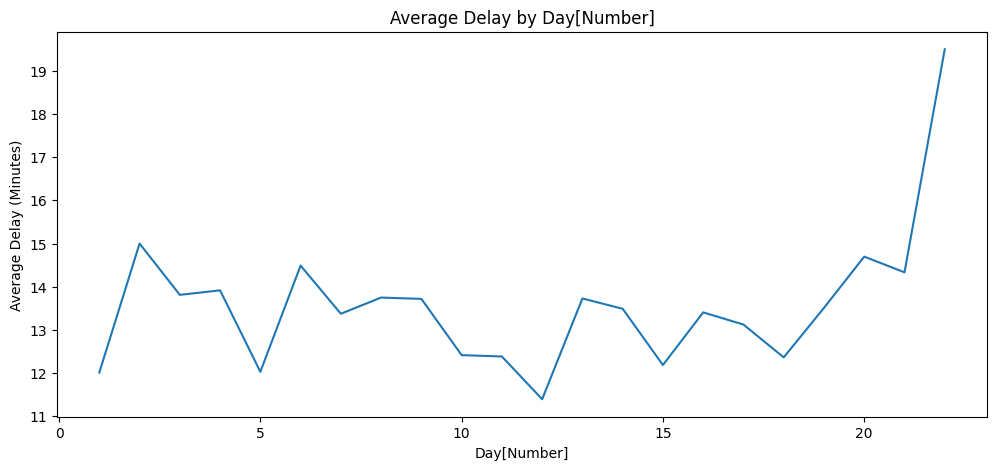

In [11]:
# Delay by Day[Number]

dayNumber_delay = df.groupby(
    "day"
)["actual_arrival_delay_min"].mean()

plt.figure(figsize=(12,5))
dayNumber_delay.plot()
plt.title("Average Delay by Day[Number]")
plt.xlabel("Day[Number]")
plt.ylabel("Average Delay (Minutes)")

Text(0, 0.5, 'Average Delay (Minutes)')

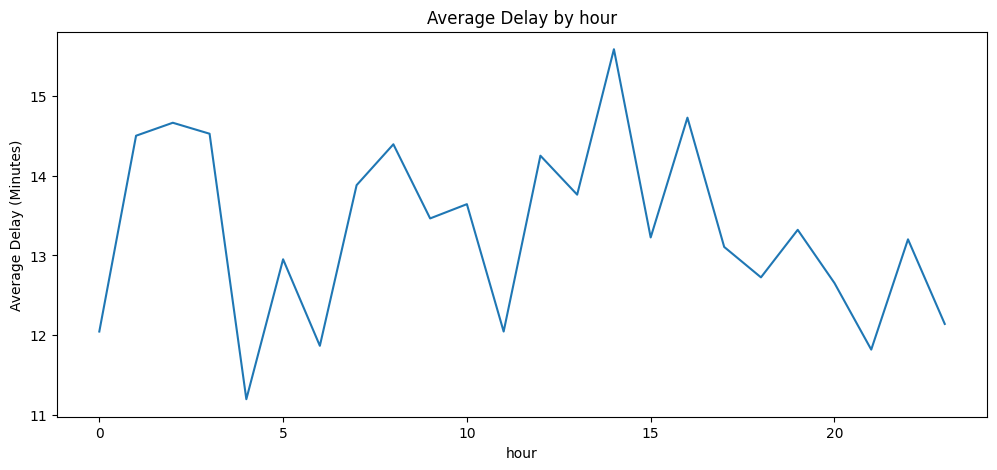

In [12]:
# Delay by hour

hour_delay = df.groupby(
    "hour"
)["actual_arrival_delay_min"].mean()

plt.figure(figsize=(12,5))
hour_delay.plot()
plt.title("Average Delay by hour")
plt.xlabel("hour")
plt.ylabel("Average Delay (Minutes)")

<Axes: xlabel='transport_type'>

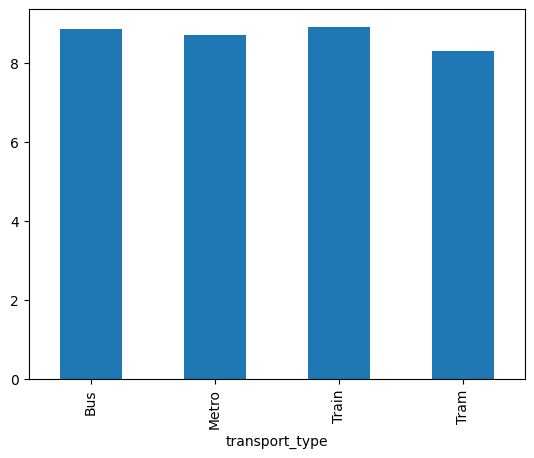

In [13]:
# Delay by transport_type

transport_type_delay = df.groupby('transport_type')['actual_departure_delay_min'].mean()
transport_type_delay.plot(kind='bar')

<Axes: xlabel='weather_condition'>

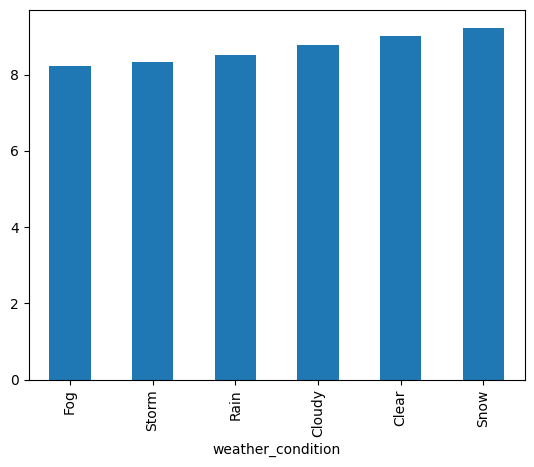

In [14]:
weather_condition_delay = df.groupby('weather_condition')['actual_departure_delay_min'].mean()
weather_condition_delay.sort_values().plot(kind='bar')



Text(0.5, 0, 'RouteIDs')

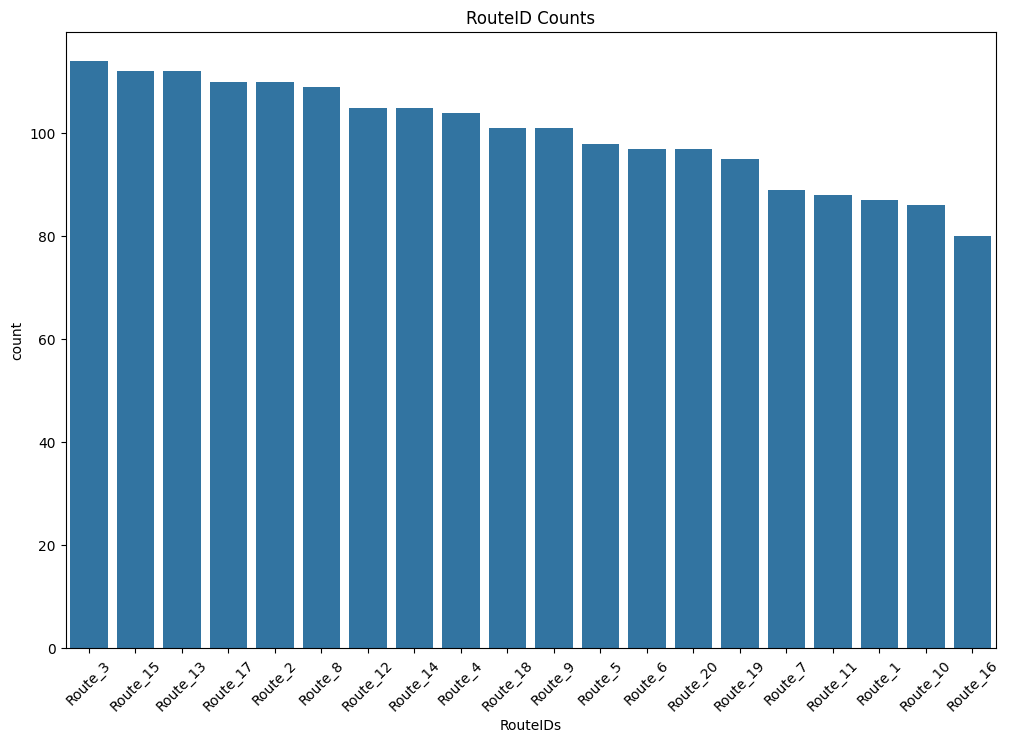

In [37]:
route = df['route_id'].value_counts().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12,8))
sns.barplot(data=route,x='route_id',y='count')
plt.xticks(rotation=45)
plt.title("RouteID Counts")
plt.xlabel("RouteIDs")

Text(0.5, 0, 'Arrival Delay (min)')

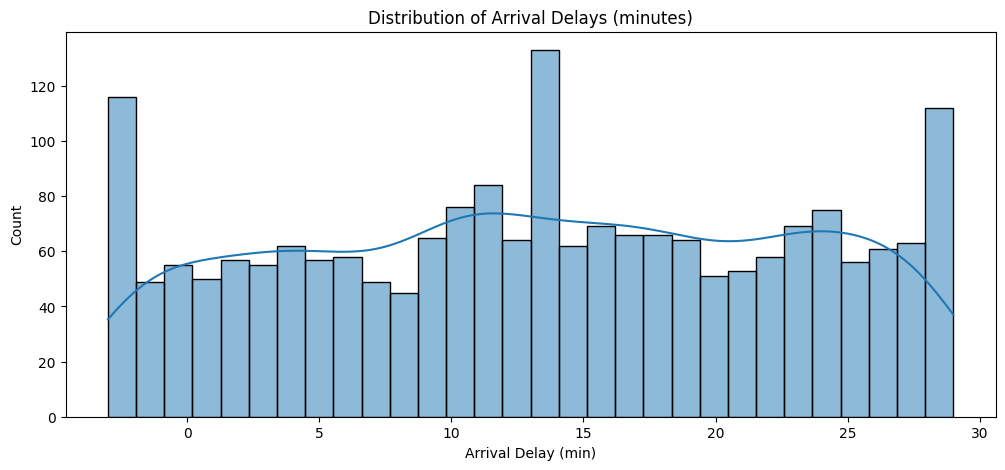

In [36]:
plt.figure(figsize=(12,5))

sns.histplot(data = df, x='actual_arrival_delay_min',bins=30,kde=True)
plt.title("Distribution of Arrival Delays (minutes)")
plt.xlabel("Arrival Delay (min)")

Text(0, 0.5, 'Avg. Delay (min)')

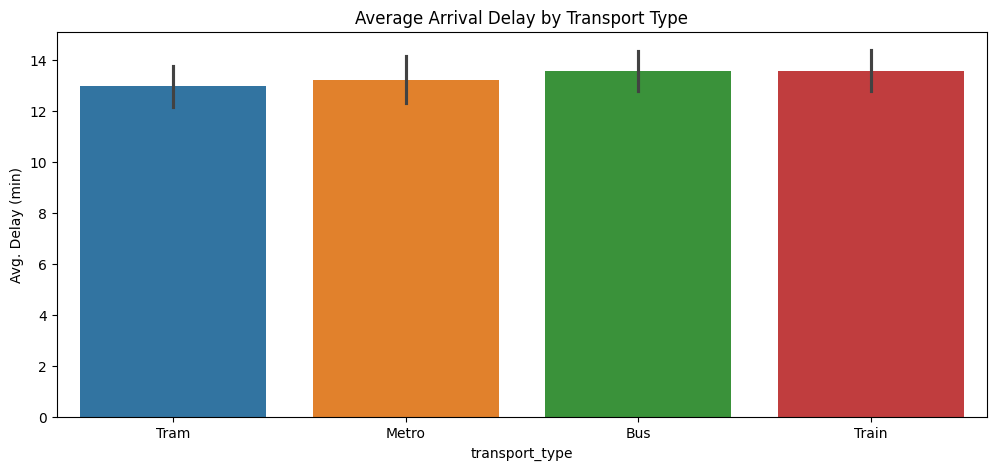

In [39]:
plt.figure(figsize=(12,5))
sns.barplot(data=df, x="transport_type", y="actual_arrival_delay_min", hue="transport_type")
plt.title("Average Arrival Delay by Transport Type")
plt.ylabel("Avg. Delay (min)")

In [28]:
df.head(5)

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed,year,month,day,hour
0,T00000,2023-01-01,2026-07-29 05:00:00,Tram,Route_15,Station_31,Station_6,2026-07-29 05:02:00,2026-07-29 05:55:00,12,...,81,0,1,6,Winter,0,2023,1,1,5
1,T00001,2023-01-01,2026-07-29 05:15:00,Metro,Route_12,Station_49,Station_32,2026-07-29 05:16:00,2026-07-29 05:55:00,15,...,53,0,0,6,Autumn,1,2023,1,1,5
2,T00002,2023-01-01,2026-07-29 05:30:00,Bus,Route_16,Station_29,Station_42,2026-07-29 05:33:00,2026-07-29 06:17:00,0,...,67,1,0,6,Autumn,0,2023,1,1,5
3,T00003,2023-01-01,2026-07-29 05:45:00,Tram,Route_19,Station_26,Station_18,2026-07-29 05:49:00,2026-07-29 06:08:00,15,...,84,0,0,6,Winter,1,2023,1,1,5
4,T00004,2023-01-01,2026-07-29 06:00:00,Tram,Route_8,Station_18,Station_15,2026-07-29 06:00:00,2026-07-29 06:35:00,-1,...,46,0,0,6,Spring,1,2023,1,1,6


In [15]:
df.columns

Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed', 'year', 'month', 'day',
       'hour'],
      dtype='str')

In [16]:
df['month'].value_counts()

month
1    2000
Name: count, dtype: int64